In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   



**팀 시즌 승률(W_PCT)와 팀의 기본 공격, 효율, 볼 운영 능력 간의 상관관계 분석**

변수 
 - Target
  W_PCT

 - Features
   PTS
   FG_PCT
   FG3_PCT
   FT_PCT
   AST
   REB
   TO

In [44]:
#------------------------------------------------
#1. 데이터 로드
#------------------------------------------------
df = pd.read_csv("../nba_dataset/games.csv")

In [45]:
df.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS'],
      dtype='object')

In [46]:
#컬럼 분리 (짧은 버전 - list comprehension)버전

home_cols = [col for col in df.columns if "_home" in col]
away_cols = [col for col in df.columns if "_away" in col]


#컬럼 분리 (for문 버전)

```python
home_cols = []
away_cols = []

for col in df.columns:
    if "_home" in col:
        home_cols.append(col)

for col in df.columns:
    if "_away" in col:
        away_cols.append(col)


In [47]:
home = df[home_cols].copy()
away = df[away_cols].copy()


home["Home"] = 1
away["Home"] = 0

In [48]:
home.columns

Index(['TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home',
       'FG3_PCT_home', 'AST_home', 'REB_home', 'Home'],
      dtype='object')

In [49]:
away.columns = [col.replace("_away", "") for col in away.columns]   
home.columns = [col.replace("_home", "") for col in home.columns]

team_games = pd.concat([home, away], axis=0, ignore_index=True)
team_games.head()

,TEAM_ID,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,Home
0,1610612740,126.0,0.484,0.926,0.382,25.0,46.0,1
1,1610612762,120.0,0.488,0.952,0.457,16.0,40.0,1
2,1610612739,114.0,0.482,0.786,0.313,22.0,37.0,1
3,1610612755,113.0,0.441,0.909,0.297,27.0,49.0,1
4,1610612737,108.0,0.429,1.000,0.378,22.0,47.0,1


In [9]:
team_avg = team_games.groupby("TEAM_ID").mean()
team_avg.head()


,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,Home
TEAM_ID,,,,,,,
1610612737,101.031987,0.453376,0.763582,0.349718,22.535915,41.966891,0.493572
1610612738,101.782562,0.459378,0.775994,0.355098,22.813929,42.032430,0.503178
1610612739,100.607182,0.451892,0.745308,0.351956,21.539779,42.988398,0.507159
1610612740,100.973852,0.454426,0.762818,0.351812,22.273678,42.784428,0.492477
1610612741,99.895632,0.446946,0.763769,0.357157,22.440159,44.074872,0.507910


In [10]:
rnk = pd.read_csv("../nba_dataset/ranking.csv")
rnk.columns

Index(['TEAM_ID', 'LEAGUE_ID', 'SEASON_ID', 'STANDINGSDATE', 'CONFERENCE',
       'TEAM', 'G', 'W', 'L', 'W_PCT', 'HOME_RECORD', 'ROAD_RECORD',
       'RETURNTOPLAY'],
      dtype='object')

In [11]:
rnk = rnk[["TEAM_ID","W_PCT"]].copy()

In [12]:
rnk.head()

,TEAM_ID,W_PCT
0,1610612743,0.633
1,1610612763,0.633
2,1610612740,0.613
3,1610612756,0.594
4,1610612746,0.576


In [13]:
team_full = team_avg.merge(rnk, on="TEAM_ID")


In [14]:
team_full.corr()


,TEAM_ID,PTS,FG_PCT,FT_PCT,FG3_PCT,AST,REB,Home,W_PCT
TEAM_ID,1.000000,-0.190545,-0.175048,-0.150050,-0.187355,-0.324643,-0.187572,-0.160475,-0.075110
PTS,-0.190545,1.000000,0.684258,0.369330,0.468926,0.622015,0.326434,-0.110546,0.127456
FG_PCT,-0.175048,0.684258,1.000000,0.159010,0.596337,0.595589,0.028576,-0.005698,0.211720
FT_PCT,-0.150050,0.369330,0.159010,1.000000,0.415847,0.070427,-0.059532,-0.246889,0.062977
FG3_PCT,-0.187355,0.468926,0.596337,0.415847,1.000000,0.392778,0.049817,-0.046480,0.176318
AST,-0.324643,0.622015,0.595589,0.070427,0.392778,1.000000,0.198346,-0.069252,0.098711
REB,-0.187572,0.326434,0.028576,-0.059532,0.049817,0.198346,1.000000,0.155926,0.073262
Home,-0.160475,-0.110546,-0.005698,-0.246889,-0.046480,-0.069252,0.155926,1.000000,0.063158
W_PCT,-0.075110,0.127456,0.211720,0.062977,0.176318,0.098711,0.073262,0.063158,1.000000


In [15]:
team_full.corr()["W_PCT"].sort_values(ascending=False)


W_PCT      1.000000
FG_PCT     0.211720
FG3_PCT    0.176318
PTS        0.127456
AST        0.098711
REB        0.073262
Home       0.063158
FT_PCT     0.062977
TEAM_ID   -0.075110
Name: W_PCT, dtype: float64

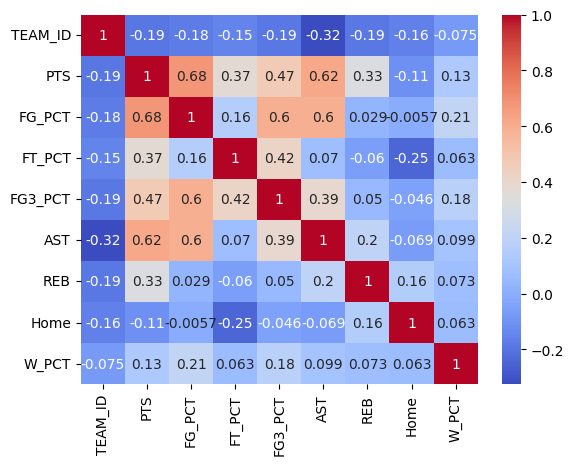

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = team_full.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


 **팀 시즌 승률 상관관계 분석 인사이트**
 
 - 팀 승률과 가장 높은 상관을 보인 지표는 야투 성공률(FG_PCT) 이었다.
 - 그 다음으로 3점 성공률(FG3_PCT), 평균 득점(PTS), 어시스트(AST) 순으로 나타났다.
 - 이는 단순한 득점량보다 슛 효율 중심의 공격력이 팀 성과에 더 중요한 요인임을 시사한다.
 - 모든 단일 지표의 상관계수는 0.3 이하로, 승률은 하나의 변수보다 여러 지표의 복합적 작용에 의해 결정됨을 보여준다.

**팀 시즌 승률(W_PCT)과 파생 슈팅 효율 지표(eFG%, TS%) 간의 상관관계 분석**

변수

- Target  
  W_PCT

- Features  
  eFG_PCT  
  TS_PCT


In [17]:
df.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS'],
      dtype='object')

In [18]:
#g_detail = pd.read_csv("../nba_dataset/games_details.csv")
#g_detail.to_parquet("../nba_dataset/games_details.parquet")


In [19]:
#------------------------------------------------
#1. 게임 상세 데이터 로드 및 파켓 변환
#------------------------------------------------
g_detail = pd.read_parquet("../nba_dataset/games_details.parquet")


In [20]:
#-------------------------------------------------
#2. 주요 컬럼 선택 및 숫자형 변환
#-------------------------------------------------
cols = ["TEAM_ID","FGM","FGA","FG3M","FTA","PTS"]
g = g_detail[cols].copy()

In [21]:
num_cols = ["FGM","FGA","FG3M","FTA","PTS"]

for c in num_cols:
    g[c] =pd.to_numeric(g[c], errors="coerce")

In [22]:
#-------------------------------------------------
#3. teamId 곁측 제거    
#-------------------------------------------------
g = g.dropna(subset=["TEAM_ID"])

In [23]:
team_sum = g.groupby("TEAM_ID").sum()
team_sum.head()


,FGM,FGA,FG3M,FTA,PTS
TEAM_ID,,,,,
1610612737,66548.0,147058.0,14669.0,41706.0,179638.0
1610612738,70541.0,154024.0,15966.0,44307.0,191326.0
1610612739,67205.0,148986.0,14967.0,43940.0,182103.0
1610612740,65085.0,143344.0,13169.0,39635.0,173528.0
1610612741,65925.0,147810.0,13187.0,40570.0,176008.0


In [24]:
#-------------------------------------------------
#4. 파생 변수 생성
#-------------------------------------------------
team_sum["eFG"] = (team_sum["FGM"] + 0.5 * team_sum["FG3M"]) / team_sum["FGA"]
team_sum["TS_PCT"] = team_sum["PTS"] / (2 * (team_sum["FGA"] + 0.44 * team_sum["FTA"]))

In [25]:
team_sum.head()

,FGM,FGA,FG3M,FTA,PTS,eFG,TS_PCT
TEAM_ID,,,,,,,
1610612737,66548.0,147058.0,14669.0,41706.0,179638.0,0.502404,0.543013
1610612738,70541.0,154024.0,15966.0,44307.0,191326.0,0.509817,0.551311
1610612739,67205.0,148986.0,14967.0,43940.0,182103.0,0.501312,0.540944
1610612740,65085.0,143344.0,13169.0,39635.0,173528.0,0.499983,0.539633
1610612741,65925.0,147810.0,13187.0,40570.0,176008.0,0.490620,0.531230


In [26]:
rnk

,TEAM_ID,W_PCT
0,1610612743,0.633
1,1610612763,0.633
2,1610612740,0.613
3,1610612756,0.594
4,1610612746,0.576
...,...,...
210337,1610612765,0.354
210338,1610612738,0.305
210339,1610612753,0.280
210340,1610612755,0.232


In [27]:
team = team_sum.merge(rnk, on="TEAM_ID")

In [28]:
team.corr()["W_PCT"].sort_values(ascending=False)

W_PCT      1.000000
PTS        0.265855
FGM        0.257385
FGA        0.249389
eFG        0.226994
TS_PCT     0.225835
FG3M       0.192964
FTA        0.170050
TEAM_ID   -0.075110
Name: W_PCT, dtype: float64

파생 슈팅 효율 지표(eFG%, TS%) 상관분석 인사이트
 - 파생 슈팅 효율 지표(eFG%, TS%)는 팀 승률과 유의한 양의 상관관계를 보였으나,
 - 득점량(PTS) 및 야투 성공 수(FGM)와 같은 볼륨 기반 지표의 상관계수가 더 높게 나타났다.
 - 이는 시즌 단위에서 승률을 설명하는 데 있어 효율성보다 공격 생산량이 더 큰 역할을 할 수 있음을 시사한다.

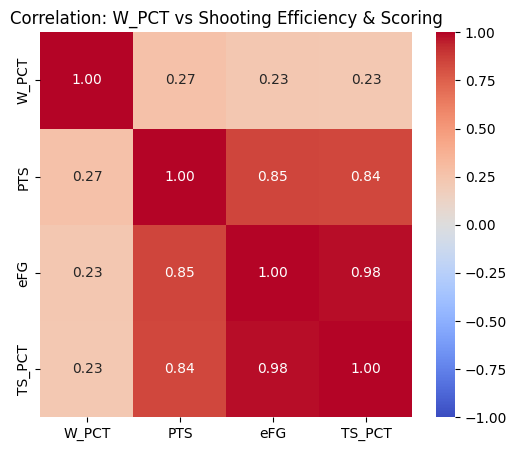

In [29]:
cols = ["W_PCT", "PTS", "eFG", "TS_PCT"]
corr_eff = team[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_eff,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1
)
plt.title("Correlation: W_PCT vs Shooting Efficiency & Scoring")
plt.show()